# Basic Querying

Alex Ronczewski  
2026-07-20

## Outline

### Prerequisites

-   Notebook 1 of this stream: what a database and a DBMS are, `SELECT`,
    `WHERE`, `ORDER BY`, and running SQL through `%%sql` cells.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Combine tables with **inner** and **left joins**, and predict how a
    join changes the number of rows.
2.  Summarize data with **aggregates** and `GROUP BY`, and state the
    **logical order** in which SQL evaluates a query, including where
    `HAVING` fits.
3.  Explain **NULL** and three-valued logic: why `= NULL` finds nothing,
    and how NULLs silently shape counts and averages.
4.  Build categories inside a query with `CASE`.
5.  Spot and fix plausible-looking wrong queries.

## 1. Where we are in the stream

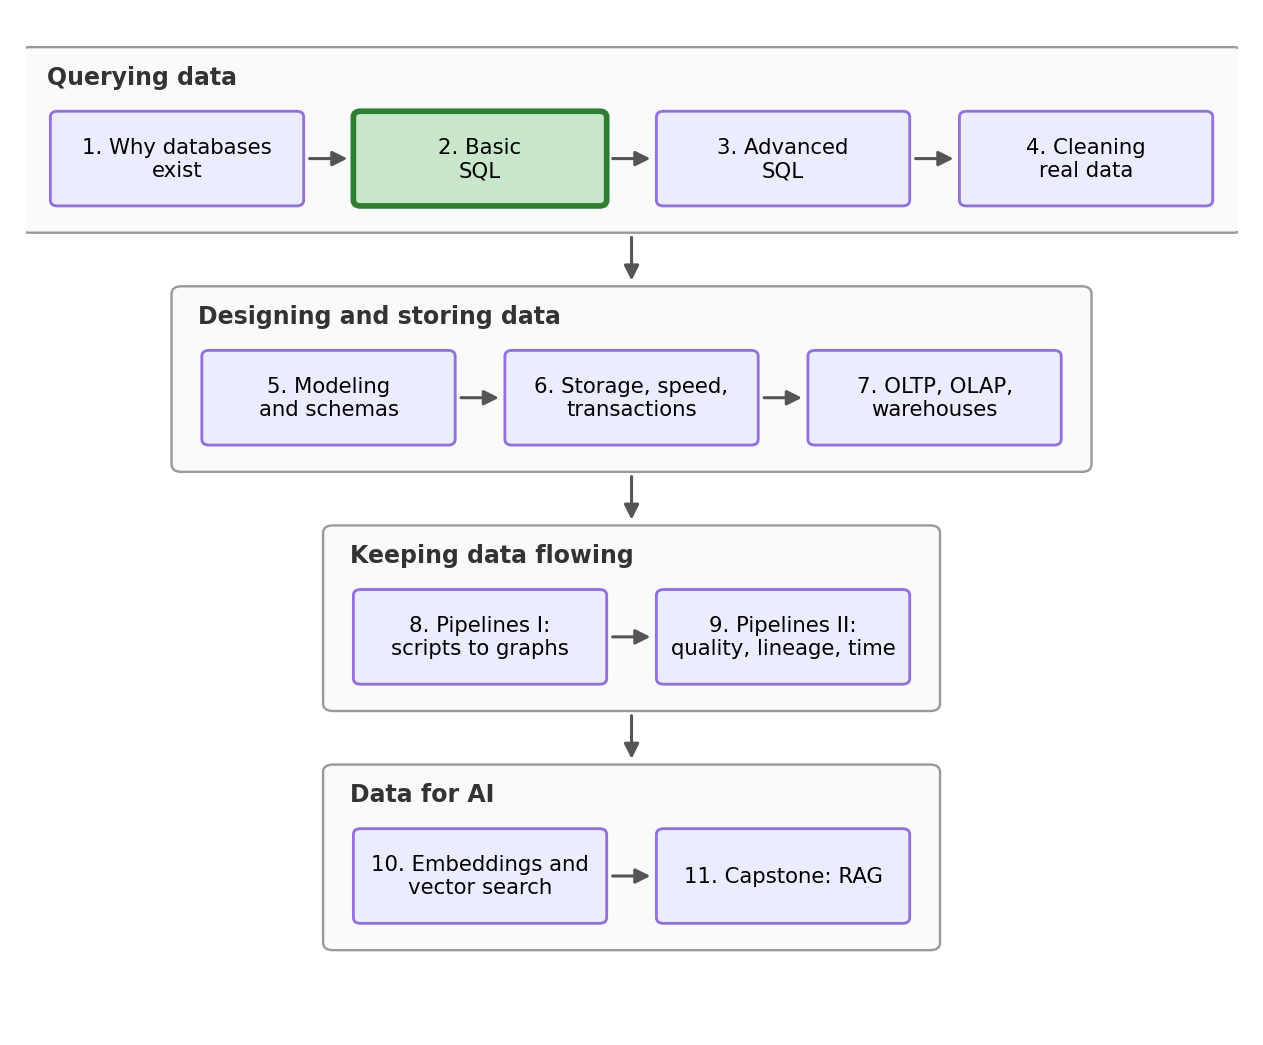

Notebook 1 ended with us looking at one table at a time. This notebook
is the core of SQL: everything an analyst does most days, and everything
a screening interview asks about, built from a single `SELECT`. SQL is
the language the world of data speaks, and it is far easier to learn
than Python, R, C++ or any other programming language. It is truly
intuitive, and with a little effort you will understand all of it. But
we can make this effort fun (hopefully at least a little).

So instead of learning it like a manual, we will learn it on the job.
You have just joined the survey’s research team as its data analyst
(congratulations!!!), and the team is writing a short report on Canadian
wages. One deliverable is yours: **a single table, wages by region,
full-time workers only, with worker counts and union shares.**

This is not a made-up type of table. Here is Statistics Canada’s
version, wages and hours by union status, from the Labour Force Survey:

<figure>
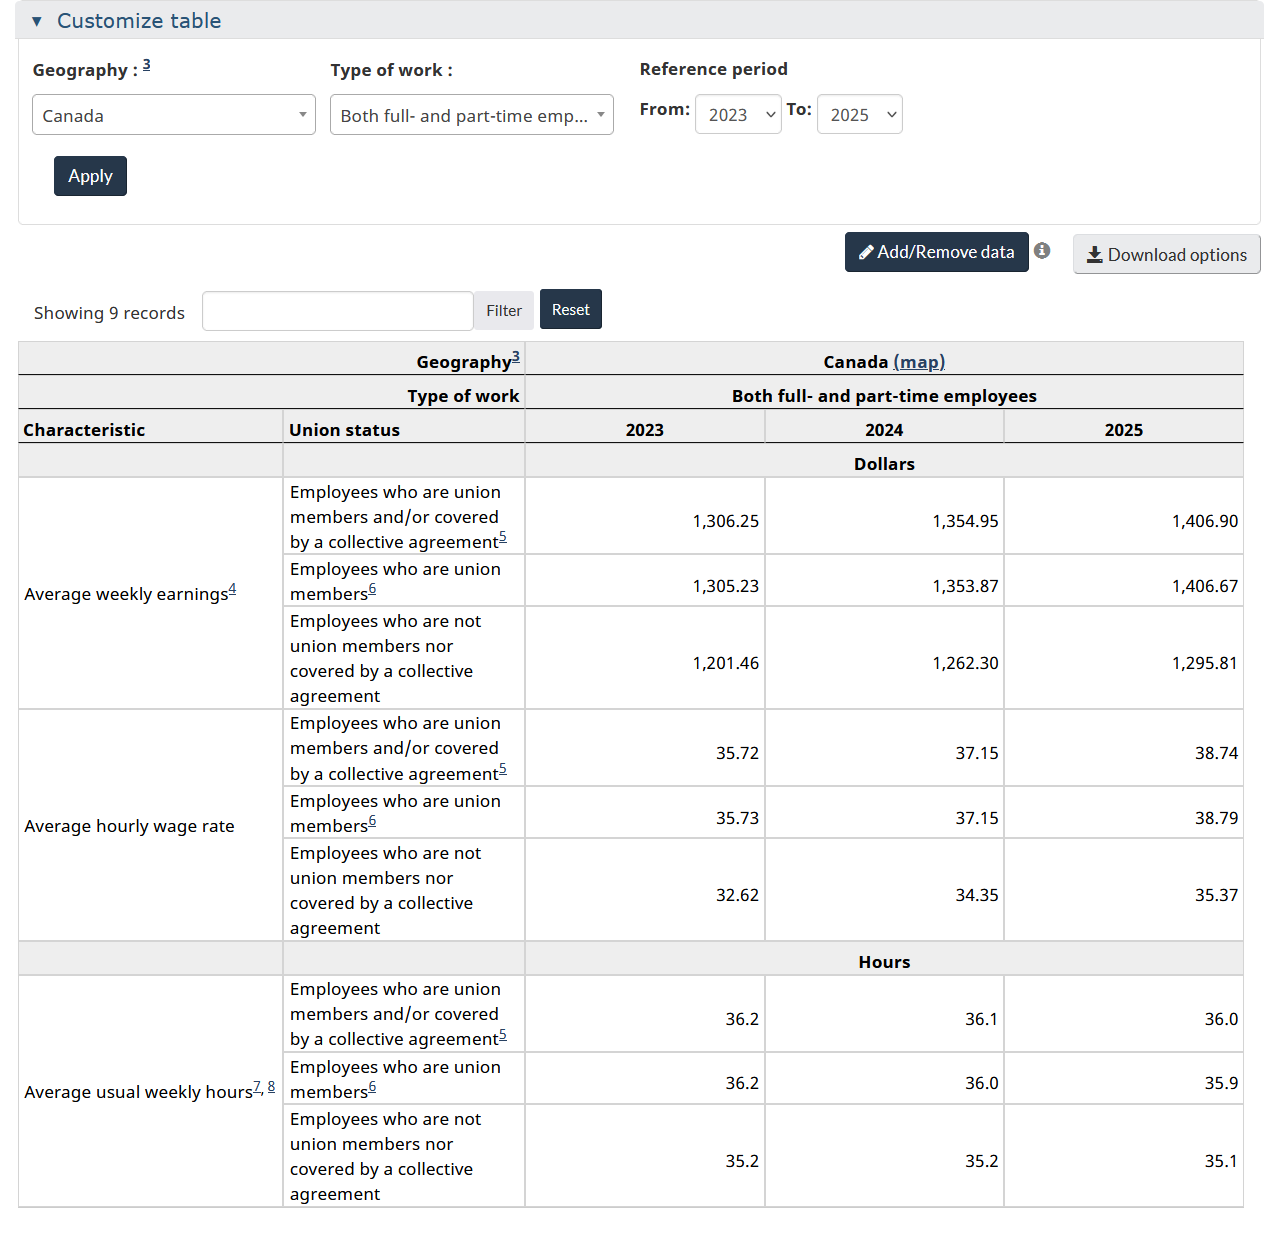
<figcaption aria-hidden="true">Statistics Canada Table 14-10-0134-01:
average weekly earnings, hourly wage rate, and usual weekly hours by
union status. Ours will be smaller and regional. And look at their 2025
hourly wages, 38.74 unionized and 35.37 not.</figcaption>
</figure>

Along the way runs a **wrong-query gallery**: plausible-looking queries
that do not do what their author wanted, sometimes with errors, but
usually silently. Your colleagues will be submitting a few of these.
Learning to catch them is a real skill.

## 2. One table becomes three

So far all of our data has lived in one table, and every question was
answered by scanning that one table. This is the largest conceptual step
from a standalone file (like a .csv) to a database.

A real database is almost never one big table. It is a collection of
tables, where each table holds **one kind of thing**: one row per survey
respondent, one row per province, one row per certification. The obvious
question is why. Why not throw everything into a single wide table? Try
it mentally with our data and it breaks in two different ways:

-   **Facts about provinces would repeat once per respondent.** British
    Columbia’s minimum wage would be stored 353 times, once in every BC
    row, and in the next few years when the rate changes, you would need
    to update all 353 copies perfectly or the data breaks. Notebook 1
    named this disease: redundancy.
-   **Certifications do not fit the survey’s shape at all.** One
    respondent holds three certifications, another holds none. Do you
    add columns `certification_1`, `certification_2`, `certification_3`,
    and break on the first person with four? Or repeat the person’s
    whole row once per certification, duplicating their wage and
    corrupting every average? Both options are bad, because “one row per
    person” is simply the wrong shape for facts that come in variable
    numbers per person.

The relational answer is to give each kind of thing its own table, store
every fact only once, and connect the tables through **shared columns**.
Here is what our database looks like from this notebook on, drawn with
real rows from each table:

<figure>
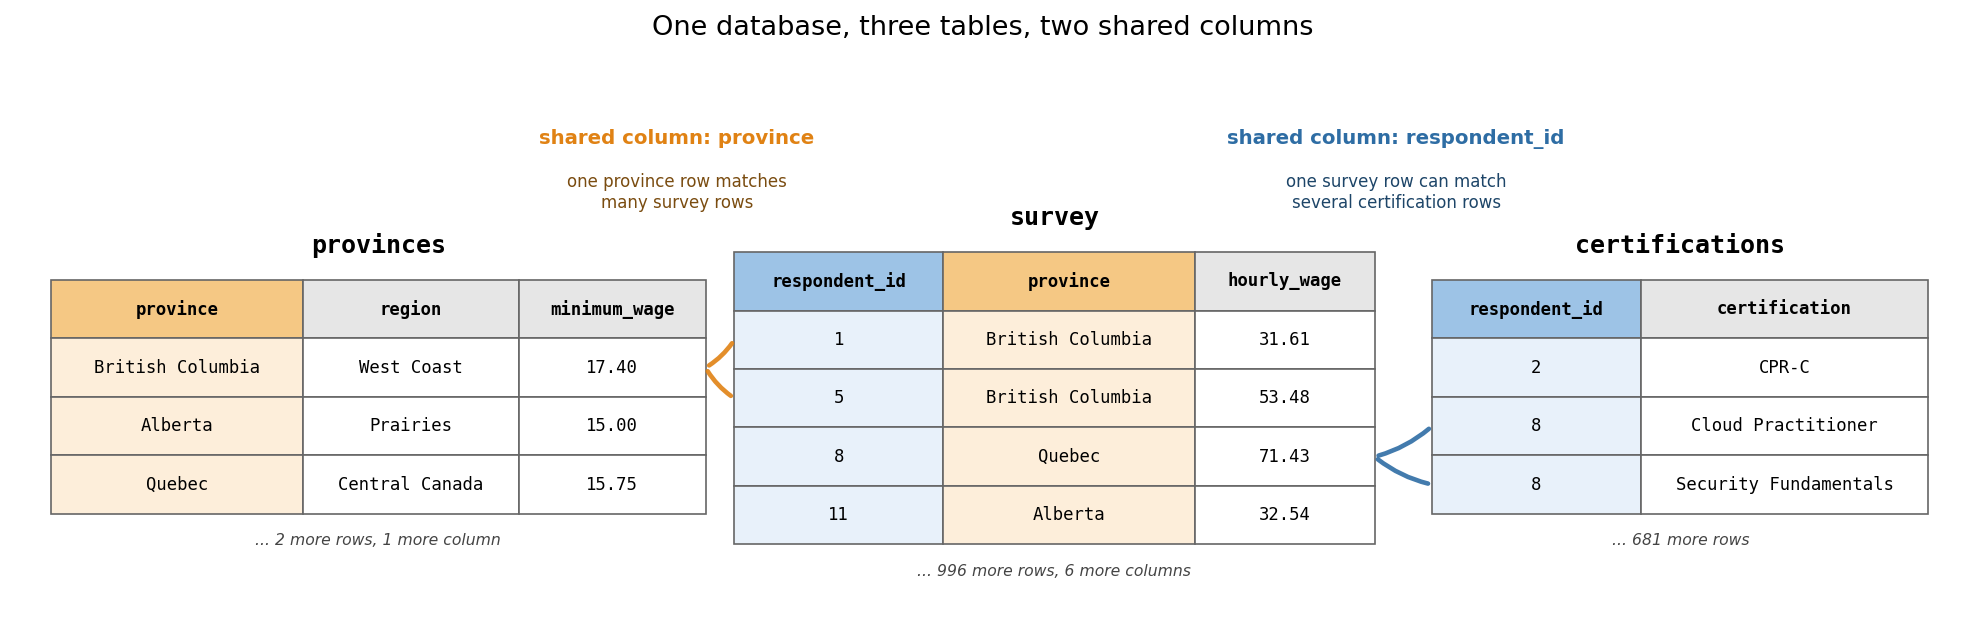
<figcaption aria-hidden="true">The survey sits in the middle, and its
two shaded columns each point into another table. The arrows trace two
example matches; every other row matches the same way.</figcaption>
</figure>

Read it row by row, following the arrows. Respondents 1 and 5 both live
in British Columbia, so both of their rows match the same single
`provinces` row: BC’s minimum wage of 17.40 is stored exactly once as
well, whether 2 respondents point at it or all 353 who live there. On
the other side, respondent 8 listed two certifications, so their one
survey row matches two `certifications` rows. The shared columns doing
the pointing, `province` on one side and `respondent_id` on the other,
are called **join keys**, and section 4 is about the command that
follows them.

First, the setup. We rebuild the database from the raw files so this
notebook can be run alone without NB1:

In [1]:
import sqlite3
import pandas as pd

In [2]:
provinces = pd.read_csv("datasets/provinces.csv")
certifications = pd.read_csv("datasets/certifications.csv")

conn = sqlite3.connect("datasets/wage_survey.db")
pd.read_csv("datasets/wage_survey.csv").to_sql("survey", conn, index=False, if_exists="replace")
provinces.to_sql("provinces", conn, index=False, if_exists="replace")
certifications.to_sql("certifications", conn, index=False, if_exists="replace")

684

The 684 that the cell reports is the row count of the last table
written, `certifications`.

In [3]:
%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.displaycon = False
%config SqlMagic.feedback = 0
%sql sqlite:///datasets/wage_survey.db

Before querying anything, look at the two new datasets side by side:

In [4]:
print(provinces.to_string(index=False))
print()
print(certifications.head(6).to_string(index=False))

        province         region  minimum_wage  population
British Columbia     West Coast         17.40     5719961
         Alberta       Prairies         15.00     4980659
        Manitoba       Prairies         15.80     1507330
         Ontario Central Canada         17.20    16176977
          Quebec Central Canada         15.75     9110616

 respondent_id         certification
             2                 CPR-C
             4     First Aid Level 1
             8    Cloud Practitioner
             8 Security Fundamentals
            10     First Aid Level 1
            10                 WHMIS

The first table, `provinces`, is a **lookup table** (also called a
reference table): one row per province. It has only five rows, one per
province, and holds values associated with each province, nothing about
any individual respondent. Unlike the survey from NB1, this data is
real. The minimum wages are the true legal rates in April 2025, from the
Government of Canada’s minimum wage database, and the populations are
Statistics Canada’s estimates for April 1, 2025; the region grouping is
ours. It fits our survey through the `province` column: every
respondent’s province should have a row here. It also matters for the
job: the briefing wants **regions**, and the survey does not have a
region column. This little table is where regions live.

The second table, `certifications`, is a new module of our simulated
survey: respondents listed the job certifications they hold, one row per
certification held. What one row stands for is different again, a
person-certificate pair rather than a person, which is why respondents 8
and 10 each appear twice in the first six rows (respondent 8 with
certifications for Cloud Practitioner and Security Fundamentals). It
fits our survey through `respondent_id`, it is important to note, not
all respondents had certifications: 548 of our 1,000 respondents listed
none and so have no rows here at all, while others have two or three.
This module is simulated because it has to be: Statistics Canada
publishes real survey microdata, but public files are anonymized before
release, and the respondent identifiers that link tables together, the
exact thing this section teaches, are among the first things
anonymization removes.

This three-table setup is a miniature of every production database you
will ever work with: a big table of people or events, lookup tables
describing the categories they belong to, and detail tables holding the
facts that come in variable numbers. The rest of the notebook is about
asking questions across all three.

## 3. Sizing up the data

Rule one of reporting on data: profile it before you summarize it.
Nobody should publish numbers from a table they have never actually
looked at, so before the briefing gets its first draft, we look into the
survey. The profiling workhorse is `DISTINCT`, which removes duplicates
from the result, every unique entry exactly once, and so answers the
question “what does this column actually contain?”

In [5]:
%%sql
SELECT DISTINCT province
FROM survey

Six provinces, each exactly once. Notebook 1’s table of typical file
failures had `BC`, `B.C.`, `bc`, and `Britsh Columbia` all meaning one
province; in a database with enforced categories, the same question is
one keyword, and if the survey held even a single row with a new
spelling, `DISTINCT` would expose it immediately.

## 4. Crossing tables: JOIN

The briefing wants wages by region. Wages live in `survey`, regions live
in `provinces`, so we can’t use a single table to answer this question.
Section 2 split our data apart and promised a command that connects it
back together; this is `JOIN`, and it is the single most important idea
in this notebook.

A **join** combines two tables by pairing up their rows wherever a
matching rule holds. The rule almost always says that a shared column
agrees on both sides, and that shared column is the **join key** from
section 2’s diagram: `province` links the survey to `provinces`, and
`respondent_id` links it to `certifications`. Use a `JOIN` whenever a
question needs columns from more than one table, which in real work is
most questions.

The classic picture of the join family looks like this, where each
circle is a table and the shading marks which rows survive:

<figure>
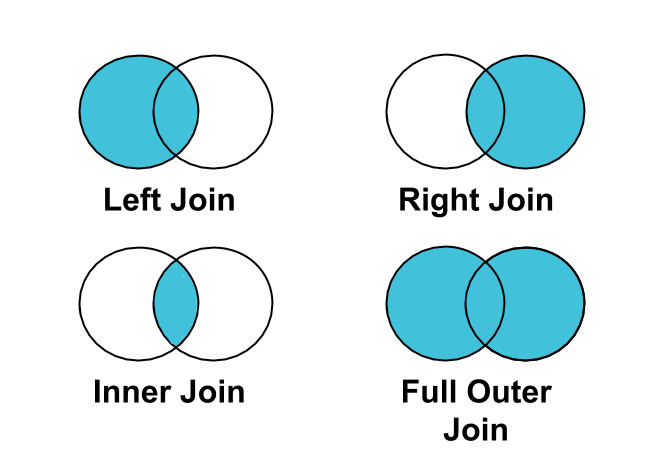
<figcaption aria-hidden="true">The two on the left are this notebook’s
tools: the inner join keeps only matched rows, the left join keeps
everything from the left table. A right join is just a left join with
the tables swapped, and a full outer join keeps everything from both
sides; both are rarer, and SQLite only gained them
recently.</figcaption>
</figure>

### 4.1 The inner join

The syntax has three new pieces:

1.  `FROM survey AS s JOIN provinces AS p` names both tables and gives
    each a short **alias** (`s` and `p`), so the rest of the query can
    refer to them without spelling the full names out.
2.  `ON s.province = p.province` is the matching rule: pair up rows
    where the provinces agree.
3.  `s.province` and `p.province` are **qualified** column names. Both
    tables have a column called `province`, so every mention has to say
    whose it is, alias first, then a dot.

> **Predict first.** `survey` has 1,000 rows and `provinces` has 5.
> Before you run the next cell, commit to a number: how many rows will
> the join return?

In [6]:
%%sql
SELECT s.respondent_id, s.province, p.region, p.minimum_wage
FROM survey AS s
JOIN provinces AS p ON s.province = p.province

954 rows × 4 columns

Each result row is a survey row with its matching province facts
attached. But read the output: **954 rows**. It’s not 1,000 or 5, and if
you predicted either, you have just learned the most useful lesson in
this section. A plain `JOIN` (an **inner join**) keeps only the rows
that find a match, and Saskatchewan’s 46 respondents found none, because
the profile in section 3 counted six provinces and our lookup table
holds five. They were dropped, and nothing warned us or printed an
error. If your next step were “average wage by region”, those 46 people
would not exist. This is a problem and your boss would not be happy.

### 4.2 The left join

A **left join** keeps every row of the left table (the one named in
`FROM`), matched or not, and fills the right table’s columns with NULL
where no match exists. Use it in two situations: when losing unmatched
rows is unacceptable (like in this case where every respondent must
count), and when the unmatched rows are themselves the thing you are
hunting for, because a left join is how you find out which of your rows
have no partner.

In [7]:
%%sql
SELECT s.respondent_id, s.province, p.region, p.minimum_wage
FROM survey AS s
LEFT JOIN provinces AS p ON s.province = p.province
ORDER BY p.region

1000 rows × 4 columns

1,000 rows, nobody dropped, and the Saskatchewan respondents sit at the
top of the sort with `None` and `NaN` where a region and minimum wage
should be. Those empty cells are **NULLs**, and in section 6 they will
come very close to ruining our briefing.

### 4.3 Joins that multiply

So far joins have shrunk our table or preserved it. They can also make
it grow.

> **Predict first.** Some respondents have no rows in `certifications`,
> some have two or three. Will joining the survey to it return more or
> fewer than 1,000 rows?

In [8]:
%%sql
SELECT s.respondent_id, s.industry, s.hourly_wage, c.certification
FROM survey AS s
JOIN certifications AS c ON s.respondent_id = c.respondent_id

684 rows × 4 columns

684 rows: the 548 respondents with no certifications vanished (inner
join, no match), while respondent 8 now appears twice, once per
certification, with their wage duplicated on both rows. Shrinking and
multiplying at the same time. So a join can shrink a table, keep it the
same size, or grow it.

## 5. The first draft

Time to draft the briefing. Its columns are summaries, worker counts,
average wages, union shares, and summaries are what **aggregates**
compute. An **aggregate function** collapses many rows into one number,
and it’s the moment SQL stops returning dataframes (lists of rows) and
starts returning answers. Five aggregates cover most of our daily needs:
`COUNT` (how many), `SUM` (the total), `AVG` (the mean), and `MIN` and
`MAX` (the extremes, which double as a quick sanity check on any numeric
column). One more keyword joins them: `AS` renames an output column, and
from here on nearly every query uses it, because aggregate columns
otherwise come back with awkward machine-made names like `COUNT(*)`, and
readable output is very valuable:

In [9]:
%%sql
SELECT COUNT(*) AS respondents,
       AVG(hourly_wage) AS avg_wage,
       MIN(hourly_wage) AS lowest,
       MAX(hourly_wage) AS highest
FROM survey

One row summarizing our data: the survey’s average wage is 38.59
dollars, and wages run from 17.40 (British Columbia’s minimum wage) up
to 113.04.

Whole-table summaries are not what the briefing wants; it compares
groups. The tell is the word *by* or *per* in a question: average wage
**by** province, respondents **per** industry. The moment you hear it,
you are writing a `GROUP BY`. It splits the rows into groups, computes
the aggregates once per group, and returns one row per group. Before
regions, a practice draft at the province level, since it needs no join:

In [10]:
%%sql
SELECT province, COUNT(*) AS respondents, AVG(hourly_wage) AS avg_wage
FROM survey
GROUP BY province
ORDER BY avg_wage DESC

This is a question Notebook 1 could not yet ask: average wage, by
province. Before quoting the table, look at the respondent counts
sitting next to the averages: Saskatchewan “leads the country” on a
sample of 46 people. Printing the count beside the mean is the habit
that keeps grouped averages trustworthy.

One clause completes the grouping toolkit. `WHERE` filters rows before
they are grouped; to filter the **groups themselves**, by their counts
or their averages, SQL has a separate keyword, `HAVING`. Why a separate
keyword exists at all comes down to the order SQL evaluates a query in:

> **The order a query actually runs in**
>
> You write `SELECT` first, but the engine evaluates in this order:
>
> `FROM` (and joins) → `WHERE` → `GROUP BY` → `HAVING` → `SELECT` →
> `ORDER BY` → `LIMIT`
>
> `WHERE` runs before groups exist, so it cannot see aggregates.
> `HAVING` runs after, so it can. This one list resolves most beginner
> confusion about SQL, and asking about it is a screening-interview
> classic.

The same idea drawn out, with the order you type on the left and the
order the engine runs on the right. Follow the crossing lines: `SELECT`
is written first and evaluated almost last.

<figure>
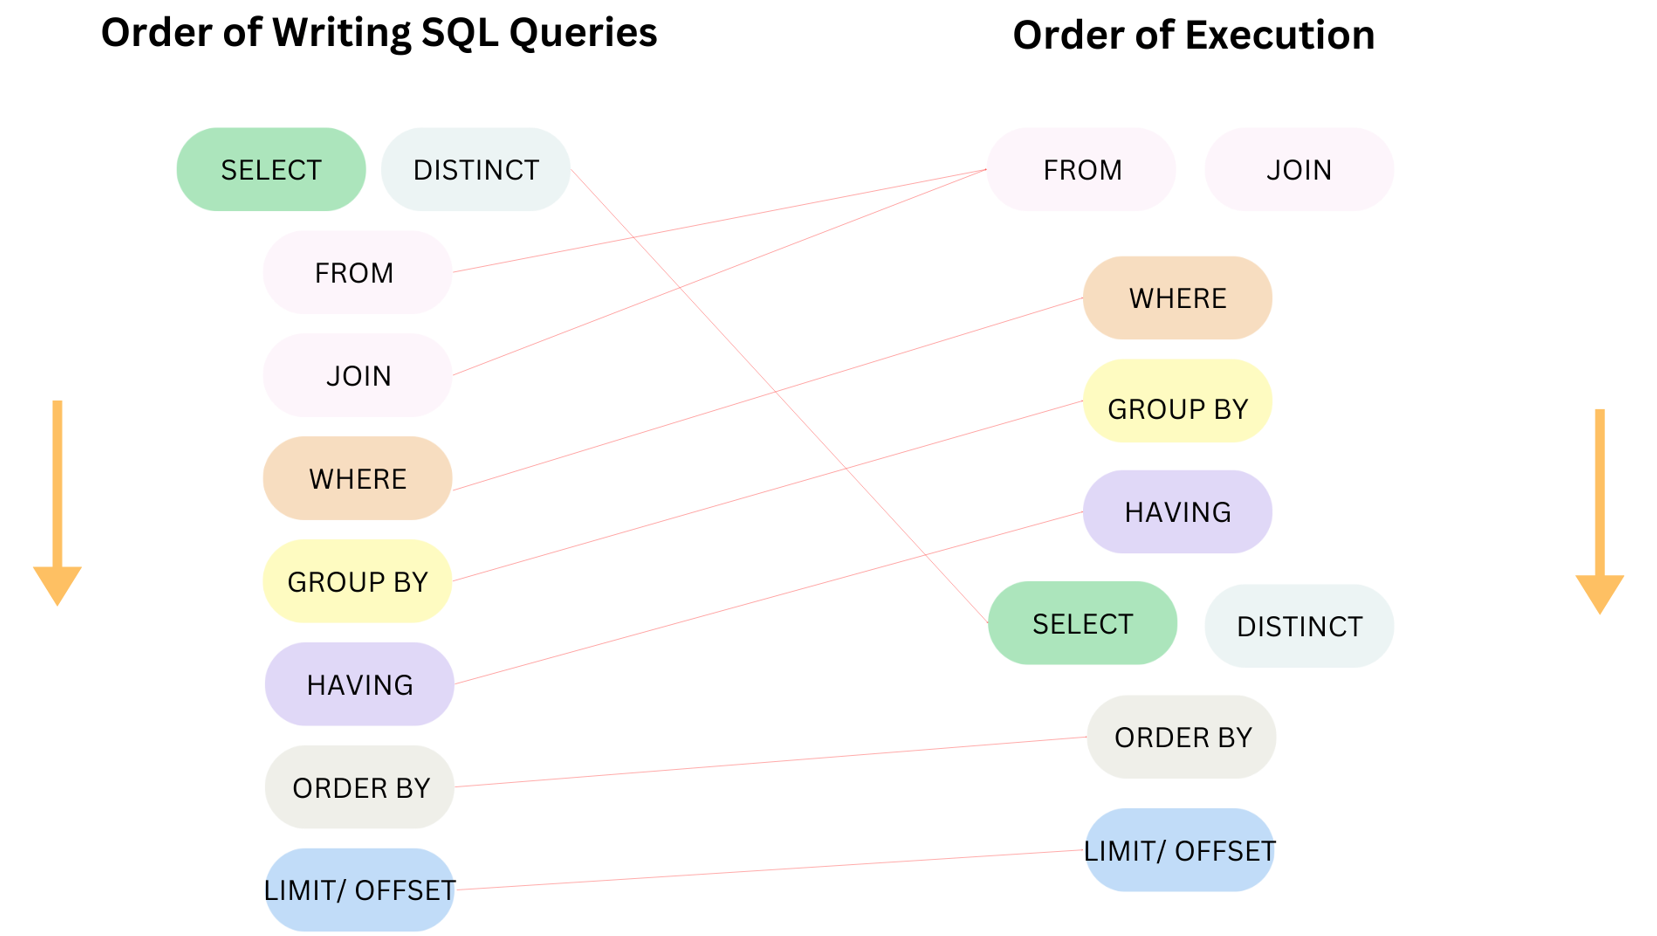
<figcaption aria-hidden="true">The order you write a query versus the
order SQL executes it. The crossing lines are exactly why
<code>WHERE</code> cannot see aggregates and <code>HAVING</code>
can.</figcaption>
</figure>

> **Wrong-query gallery #1**
>
> A colleague wants the industries that pay 40 dollars an hour or more
> on average, and writes:
>
> ``` python
> %%sql
> SELECT industry, AVG(hourly_wage) AS avg_wage
> FROM survey
> WHERE AVG(hourly_wage) >= 40
> GROUP BY industry
> ```
>
>     RuntimeError: (sqlite3.OperationalError) misuse of aggregate: AVG()
>     [SQL: SELECT industry, AVG(hourly_wage) AS avg_wage
>     FROM survey
>     WHERE AVG(hourly_wage) >= 40
>     GROUP BY industry]
>     (Background on this error at: https://sqlalche.me/e/20/e3q8)
>
> This one does not fail silently: SQLite refuses to run it. Read the
> error message: `misuse of aggregate`. Why is an aggregate misused
> here?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> Follow the evaluation order: `WHERE` runs before `GROUP BY`, at a
> point where the engine is looking at individual rows and no groups or
> averages exist yet, so an aggregate inside `WHERE` is meaningless and
> SQL rejects it. Filtering on an aggregate is exactly what `HAVING` is
> for. Enjoy this error, it is one of the few times SQL stops you
> instead of handing back a wrong number. The corrected syntax:
>
> ``` python
> %%sql
> SELECT industry, AVG(hourly_wage) AS avg_wage
> FROM survey
> GROUP BY industry
> HAVING AVG(hourly_wage) >= 40
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     | industry              | avg_wage  |
> |-----|-----------------------|-----------|
> | 0   | Construction          | 40.484393 |
> | 1   | Finance               | 48.986667 |
> | 2   | Public administration | 40.421190 |
> | 3   | Technology            | 48.957917 |
>
> </div>
>
> Four industries clear the bar.
>
> </details>

> **Your turn.** The team also wants education numbers. Using only the
> `survey` table: for each education level, return the number of
> respondents and their average hourly wage, best paid group first.
> Start the cell with `%%sql`. If it is right, it returns 4 rows, with
> graduate degrees on top at just over 50 dollars an hour.

In [13]:
# your query here

Show / hide answer

In [14]:
%%sql
SELECT education, COUNT(*) AS respondents, AVG(hourly_wage) AS avg_wage
FROM survey
GROUP BY education
ORDER BY avg_wage DESC

## 6. The wrong number we almost published

The briefing asks for regions, not provinces, so the real draft needs
section 4’s join and section 5’s grouping working together.

> **Predict first.** The lookup table maps five provinces into three
> regions. How many rows will the regional table have?

In [15]:
%%sql
SELECT p.region, COUNT(*) AS workers, AVG(s.hourly_wage) AS avg_wage
FROM survey AS s
JOIN provinces AS p ON s.province = p.province
GROUP BY p.region

Three regions, with sensible looking averages, a table you could paste
straight into the report. Before we do, apply section 5’s habit and read
the counts: 414 + 187 + 353 = 954. We surveyed 1,000 people. Where are
the other 46?

Inner join dropped every respondent whose province has no row in
`provinces`, and Saskatchewan has no row. Those people are findable,
since the left join keeps them with NULL where a region should be. NULL
is SQL’s marker for “no value here”, and it does not behave like a
value. Watch what happens when we hunt for the missing rows with
`WHERE`:

In [16]:
%%sql
SELECT s.respondent_id, s.province, p.region
FROM survey AS s
LEFT JOIN provinces AS p ON s.province = p.province
WHERE p.region = NULL

Zero rows, even though we watched 46 of them appear in section 4. The
query looks correct, SQL raised no error, and the rows just aren’t
there. The reason for this is that: **`= NULL` is never true, for
anything, including NULL itself.** NULL means “unknown”, and SQL’s logic
is **three-valued**: a comparison can be true, false, or unknown, and
any comparison against an unknown is itself unknown (think of this like
undefined in math). `WHERE` keeps only the rows whose condition is true,
so unknown is discarded just like false. Finding NULLs therefore has its
own dedicated command, `IS NULL` (and its opposite, `IS NOT NULL`):

In [17]:
%%sql
SELECT COUNT(*) AS missing_region
FROM survey AS s
LEFT JOIN provinces AS p ON s.province = p.province
WHERE p.region IS NULL

All 46, accounted for; excellent. Now the correct version of the
regional draft. Rerun it with a left join, and `GROUP BY` does something
helpful on its own: it collects all the NULLs into a group of their own:

In [18]:
%%sql
SELECT p.region, COUNT(*) AS workers, AVG(s.hourly_wage) AS avg_wage
FROM survey AS s
LEFT JOIN provinces AS p ON s.province = p.province
GROUP BY p.region

The `None` row is Saskatchewan, and it has the **highest** average wage
in the table. Our three-region draft omitted 46 individuals who were the
highest paid group in the survey and skewed every comparison in the
process. Nothing crashed, no error warned us, and the wrong table even
looked cleaner than the right one.

NULL causes chaos outside databases too. In 2016 a security researcher
registered the custom license plate `NULL`, and whenever officers left
the plate field blank on a citation, the system matched it to him:

<figure>
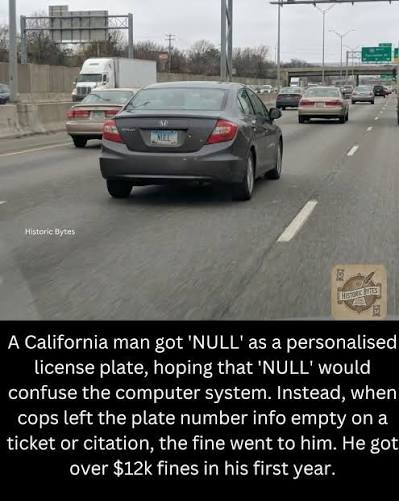
<figcaption aria-hidden="true">A real story: the researcher known as
droogie told it at the DEF CON 27 security conference in 2019. Thousands
of dollars of other people’s fines routed to one man, because a blank
field and the string NULL are not the same thing, until some system
decides they are.</figcaption>
</figure>

## 7. Comparing fairly: CASE

The briefing spec says full-time workers only, and the survey has hours,
not a full-time indicator column. `CASE` is SQL’s if-else, and it builds
new columns out of conditions. Use it whenever the category you want to
analyze does not exist as a column yet: banding a continuous variable,
collapsing detailed codes into coarse groups, or building a dummy
variable. Statistics Canada draws the full-time line at 30 hours a week,
so let us build it (we will call it work_status) and summarize both
groups:

In [19]:
%%sql
SELECT CASE WHEN weekly_hours >= 30 THEN 'Full-time' ELSE 'Part-time' END AS work_status,
       COUNT(*) AS respondents,
       AVG(hourly_wage) AS avg_wage
FROM survey
GROUP BY work_status

819 full-timers, 181 part-timers, similar hourly wages. Notice the
composition: `CASE` invents a column that exists nowhere in the table,
and `GROUP BY` groups on it. A `CASE` can also hold many `WHEN`
branches, checked top to bottom with the first match winning, which is
how you band a numeric column into exclusive groups.

## 8. The final deliverable

We are ready! The end product we need is: wages by region, full-time
workers only, with worker counts and union shares, and we will report
only regions with at least 50 such workers. Two small things appear
inside it. `ROUND(value, 2)` rounds a number to the given count of
decimal places, two here, so the summary columns come back readable
instead of trailing twelve decimals. And for the union share we will do
a simple trick: `union_member` holds 0 or 1, and the average of a 0/1
column is a share, so `AVG(s.union_member)` is exactly the union share
we need.

In [20]:
%%sql
SELECT p.region,
       COUNT(*) AS workers,
       ROUND(AVG(s.hourly_wage), 2) AS avg_wage,
       ROUND(AVG(s.union_member), 2) AS union_share
FROM survey AS s
LEFT JOIN provinces AS p ON s.province = p.province
WHERE s.weekly_hours >= 30
GROUP BY p.region
HAVING COUNT(*) >= 50
ORDER BY avg_wage DESC

Read it in evaluation order, the same list from section 5: the join
builds person-region rows, `WHERE` keeps the 819 full-timers, `GROUP BY`
folds them into regions, `HAVING` keeps regions with 50 or more,
`SELECT` computes and rounds the summaries, and `ORDER BY` sorts the
surviving entries.

> **Think Deeper.** `AVG(union_member)` works because the mean of a
> dummy variable is a proportion. You have used this fact all through
> your econometrics education: it is why a regression of a 0/1 outcome
> on a constant returns the sample share. The trick carries over to any
> yes/no column you encounter.

One thing to consider: Saskatchewan’s full-timers, 36 of them, formed a
NULL-region group, and the 50-worker floor in `HAVING` dropped it. That
is the same group that we lost in section 6, but with one difference:
this time we know, we chose the threshold, and we state this clearly in
the meeting and final report. Dropping data can be okay, and sometimes
it’s the correct choice outright. Dropping data without knowing is how
wrong numbers get published and is always bad.

## 9. The question we cannot answer yet

The report is out, and a co-worker immediately asks the natural
follow-up: **do certified workers earn more?** We have a certifications
table; it feels like one join away.

It depends on a definition. The **grain** of a table is what one row
stands for. In `survey`, a row is a person; in the certification join
from section 4.3, a row is a person-certification pair. Aggregates count
rows, so they answer questions at the grain of the table they are given,
whether or not that is the question you asked.

> **Wrong-query gallery #2**
>
> How many respondents hold at least one certification? A colleague
> joins and counts:
>
> ``` python
> %%sql
> SELECT COUNT(*) AS certified_respondents
> FROM survey AS s
> JOIN certifications AS c ON s.respondent_id = c.respondent_id
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     | certified_respondents |
> |-----|-----------------------|
> | 0   | 684                   |
>
> </div>
>
> 684 certified respondents. What is wrong, and what is the real number?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> 684 is the number of **certifications**, because the join has one row
> per person-certification pair and respondent 8 is being counted once
> per certificate. The question asks about people, and
> `COUNT(DISTINCT s.respondent_id)` counts each person once. Whenever a
> query involves a join, decide what one row means before you aggregate.
> The corrected syntax:
>
> ``` python
> %%sql
> SELECT COUNT(DISTINCT s.respondent_id) AS certified_respondents
> FROM survey AS s
> JOIN certifications AS c ON s.respondent_id = c.respondent_id
> ```
>
> <div>
> <style scoped>
>     .dataframe tbody tr th:only-of-type {
>         vertical-align: middle;
>     }
>
>     .dataframe tbody tr th {
>         vertical-align: top;
>     }
>
>     .dataframe thead th {
>         text-align: right;
>     }
> </style>
>
> |     | certified_respondents |
> |-----|-----------------------|
> | 0   | 452                   |
>
> </div>
>
> The real number is 452.
>
> </details>

Counting people was rescued by `COUNT(DISTINCT ...)`. The average wage
is where this breaks:

In [23]:
%%sql
SELECT AVG(s.hourly_wage) AS avg_wage_certified
FROM survey AS s
JOIN certifications AS c ON s.respondent_id = c.respondent_id

39.89 dollars an hour, and we know before publication that it is
computed at the wrong grain: every multi-certificate respondent’s wage
is counted once per certificate, so the heavily certified pull the
average toward themselves. What we want is the average over **one row
per certified person**. With this notebook’s tools, a single `SELECT`,
we are stuck. You would need to first collapse the join down to one row
per person, and then average the result, which means running a query on
the output of another query. A query inside a query.

That is exactly where Notebook 3 begins.

## 10. Conclusion

The briefing shipped, and it was correct! Getting one table right took
joins, aggregates, group filters, a manufactured column, and three close
calls: a hunt for missing rows that came back empty because `= NULL` is
never true, an inner join that deleted the best-paid group in the data,
and a count taken at the wrong grain. They were queries that ran without
throwing an error.

Thanks for sticking with me; SQL is the language of modern data and
databases. It is a useful skill and the language itself is very
human-readable with limited obfuscations and weird issues (most of which
we discussed above). The coming notebooks will be more fun with more
interesting real life examples. This notebook was much more computer
science and code syntax, but it is worth it! With a little more practice
you can write SQL as a skill on your resume and a whole bunch of jobs
after graduation open up for you.

> **You can now answer these interview questions**
>
> -   What is the difference between an inner join and a left join, and
>     how can a join change the number of rows?
> -   Why can `COUNT(column)` be smaller than `COUNT(*)`?
> -   When do you filter with `WHERE` and when with `HAVING`?
> -   Why does `WHERE x = NULL` return nothing, and what do you write
>     instead?
>
> <details>
>
> <summary>
>
> Show / hide model answers
>
> </summary>
>
> -   An inner join keeps only rows that find a match; a left join keeps
>     every left-table row and fills unmatched columns with NULL. Row
>     counts shrink when rows fail to match, and grow when a row matches
>     several partners, one output row per matching pair.
> -   `COUNT(*)` counts rows; `COUNT(column)` counts only non-NULL
>     values in that column, so every NULL widens the gap.
> -   `WHERE` filters individual rows before grouping and cannot see
>     aggregates; `HAVING` filters whole groups after `GROUP BY` and
>     can.
> -   Comparisons with NULL evaluate to unknown rather than true, so the
>     filter keeps nothing; write `x IS NULL` (or `x IS NOT NULL`).
>
> </details>

## Appendix: where to practice

Everything in this notebook is interview material, and the way to make
it permanent is repetitions on someone else’s data and questions. Three
free sites are the standard tools:

-   [DataLemur](https://datalemur.com): SQL questions taken from real
    company interviews, with a generous free tier.
-   [StrataScratch](https://www.stratascratch.com): interview questions
    you can solve in SQL or Python `pandas`.
-   [LeetCode SQL 50](https://leetcode.com/studyplan/top-sql-50/): the
    classic curated list; its easy tier maps almost exactly onto this
    notebook.

You are ready for the easy tier of all three right now: it is `SELECT`,
`WHERE`, joins, and `GROUP BY`, which is what we just learned.

<figure>
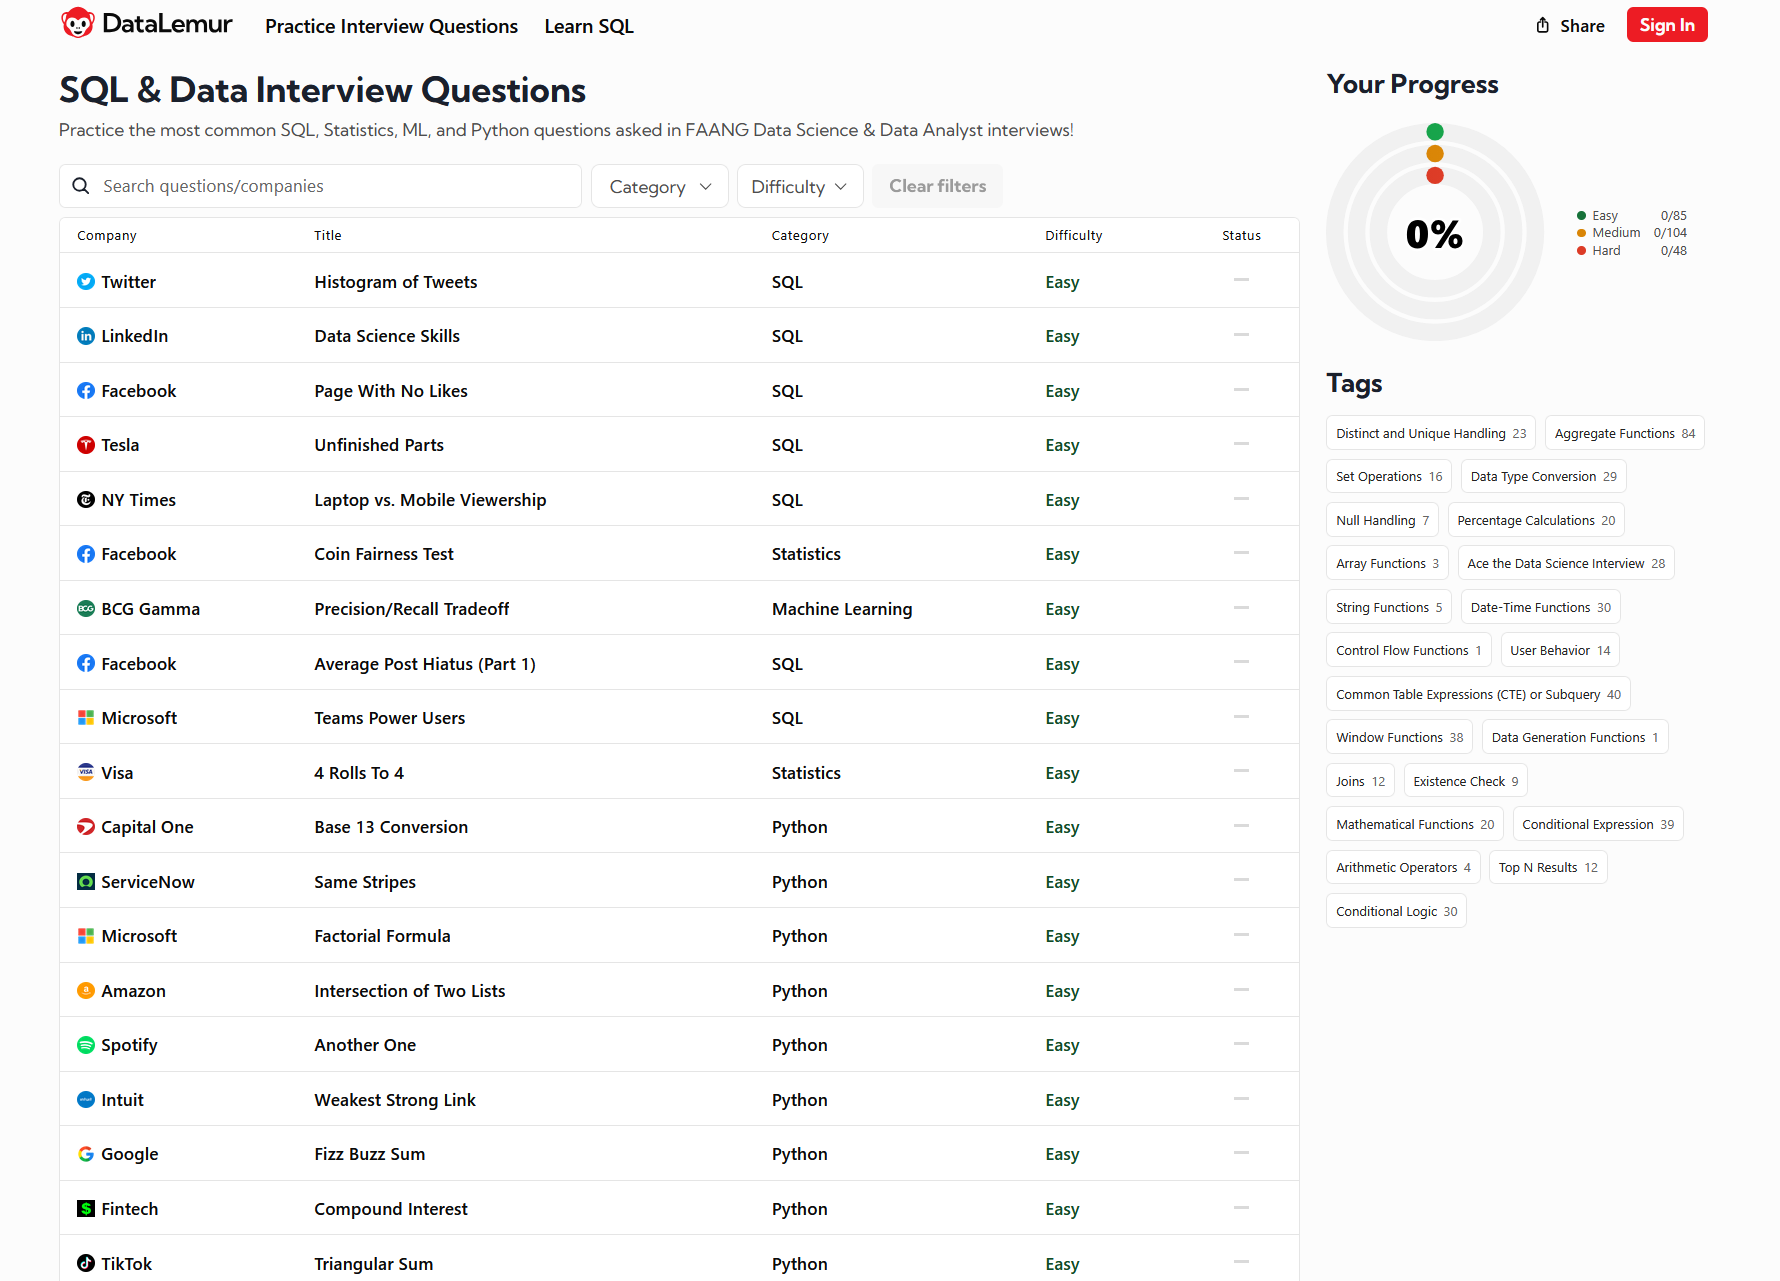
<figcaption aria-hidden="true">DataLemur’s question board. Read the tag
cloud on the right: Aggregate Functions, Joins, Distinct and Unique
Handling, Null Handling, Conditional Logic. Every one of those tags is a
section of this notebook.</figcaption>
</figure>

## Connections

-   **Back to [Notebook 1](notebook_01_why_databases_exist.qmd):** there
    we built the database and asked one-table questions; here the
    database grew to three tables.
-   **Forward to [Notebook 3](notebook_03_advanced_sql.qmd):** the
    certified-wage question needs a query that runs on the output of
    another query. Subqueries, CTEs, and views, window functions,
    changing data with INSERT and UPDATE, and how to run SQL from Python
    safely, including what a SQL injection is.

### References

-   Government of Canada. *Current and forthcoming general minimum wage
    rates in Canada.*
    https://minwage-salairemin.service.canada.ca/en/general.html The
    source of the minimum wages in `provinces.csv` (rates in force April
    2025).
-   Malan, D. (2024). *CS50’s Introduction to Databases with SQL.*
    Harvard University. https://cs50.harvard.edu/sql/ (Lecture 1,
    Relating, covers joins.)
-   ThoughtSpot (formerly Mode). *SQL tutorial.*
    https://www.thoughtspot.com/sql-tutorial A free reference that
    extends everything here.
-   SQLite. *The SELECT statement.*
    https://www.sqlite.org/lang_select.html
-   SQLite. *NULL handling in SQLite.* https://www.sqlite.org/nulls.html
    Three-valued logic, from the engine’s own documentation.
-   Statistics Canada. *Average weekly earnings, average hourly wage
    rate and average usual weekly hours by union status, annual.* Table
    14-10-0134-01.
    https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1410013401 The
    real-world version of this notebook’s deliverable, shown in section
    1.
-   Statistics Canada. (2025). *Canada’s population estimates, first
    quarter 2025.* The Daily, June 18, 2025.
    https://www150.statcan.gc.ca/n1/daily-quotidien/250618/dq250618a-eng.htm
    The source of the populations in `provinces.csv`.

------------------------------------------------------------------------